## Scatter Plot with Marginal Histograms (Matplotlib only)

Concept

Center: scatter plot

Top: histogram of X

Right: histogram of Y

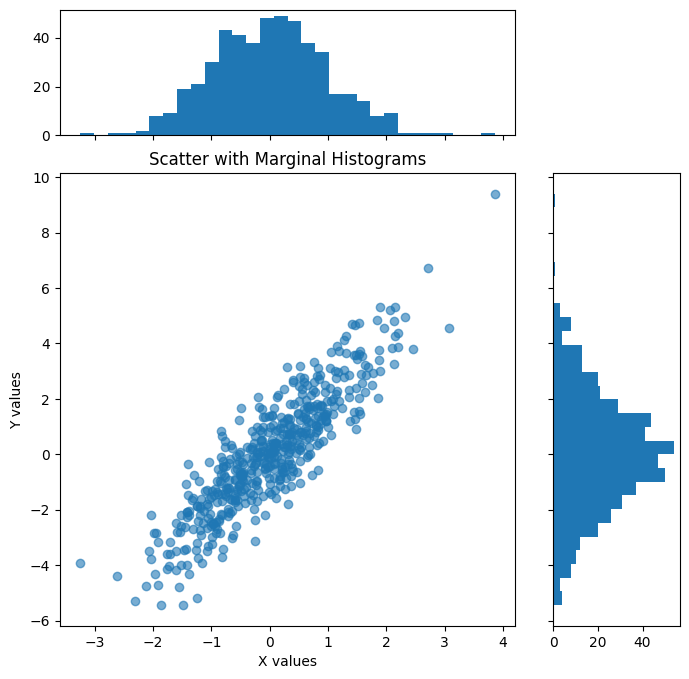

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
x = np.random.normal(loc=0, scale=1, size=500)
y = 2 * x + np.random.normal(0, 1, size=500)

# Create figure layout
fig = plt.figure(figsize=(8, 8))

# Grid layout
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

ax_scatter = fig.add_subplot(grid[1:, :-1])
ax_histx = fig.add_subplot(grid[0, :-1], sharex=ax_scatter)
ax_histy = fig.add_subplot(grid[1:, -1], sharey=ax_scatter)

# Scatter plot
ax_scatter.scatter(x, y, alpha=0.6)
ax_scatter.set_xlabel("X values")
ax_scatter.set_ylabel("Y values")
ax_scatter.set_title("Scatter with Marginal Histograms")

# Histograms
ax_histx.hist(x, bins=30)
ax_histy.hist(y, bins=30, orientation='horizontal')

# Remove tick labels for cleaner look
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

plt.show()


## Scatter Plot with Marginal Boxplots

🔹 Concept

Center: scatter

Top: boxplot of X

Right: boxplot of Y

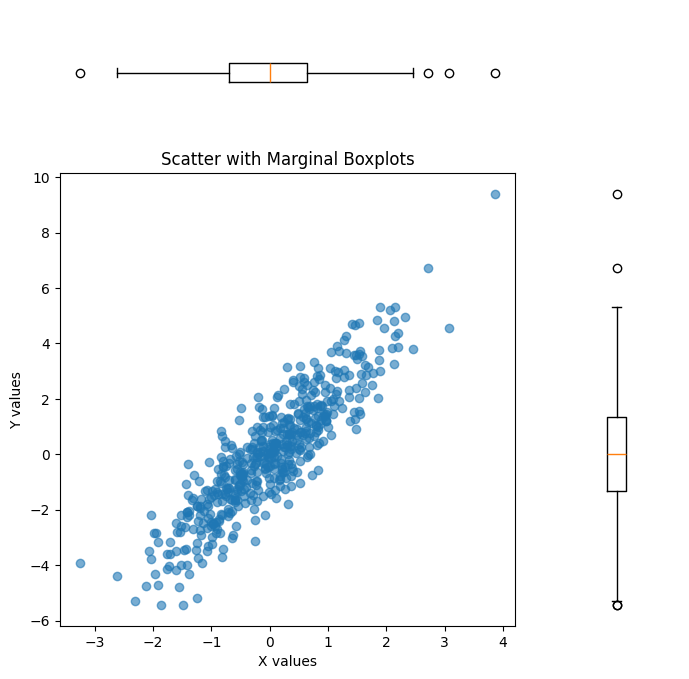

In [2]:
fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

ax_scatter = fig.add_subplot(grid[1:, :-1])
ax_boxx = fig.add_subplot(grid[0, :-1], sharex=ax_scatter)
ax_boxy = fig.add_subplot(grid[1:, -1], sharey=ax_scatter)

# Scatter
ax_scatter.scatter(x, y, alpha=0.6)
ax_scatter.set_xlabel("X values")
ax_scatter.set_ylabel("Y values")
ax_scatter.set_title("Scatter with Marginal Boxplots")

# Boxplots
ax_boxx.boxplot(x, vert=False)
ax_boxy.boxplot(y, vert=True)

# Clean axes
ax_boxx.axis("off")
ax_boxy.axis("off")

plt.show()


## Scatter with Histogram + KDE overlay (Advanced Look)

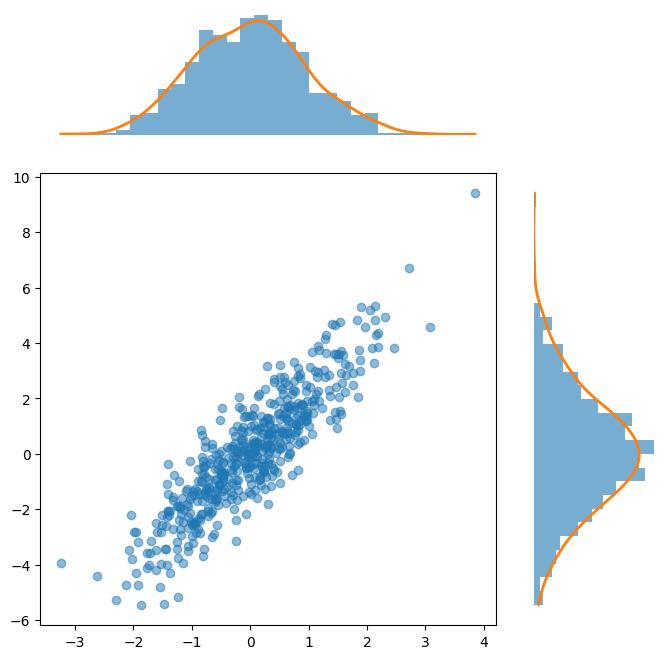

In [3]:
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)

ax_scatter = fig.add_subplot(grid[1:, :-1])
ax_histx = fig.add_subplot(grid[0, :-1], sharex=ax_scatter)
ax_histy = fig.add_subplot(grid[1:, -1], sharey=ax_scatter)

ax_scatter.scatter(x, y, alpha=0.5)

# X KDE
xs = np.linspace(x.min(), x.max(), 300)
kde_x = gaussian_kde(x)
ax_histx.hist(x, bins=30, density=True, alpha=0.6)
ax_histx.plot(xs, kde_x(xs), linewidth=2)

# Y KDE
ys = np.linspace(y.min(), y.max(), 300)
kde_y = gaussian_kde(y)
ax_histy.hist(y, bins=30, density=True, orientation='horizontal', alpha=0.6)
ax_histy.plot(kde_y(ys), ys, linewidth=2)

ax_histx.axis("off")
ax_histy.axis("off")

plt.show()


## One-Line Alternative (Seaborn – FYI)

If you ever want a shortcut:

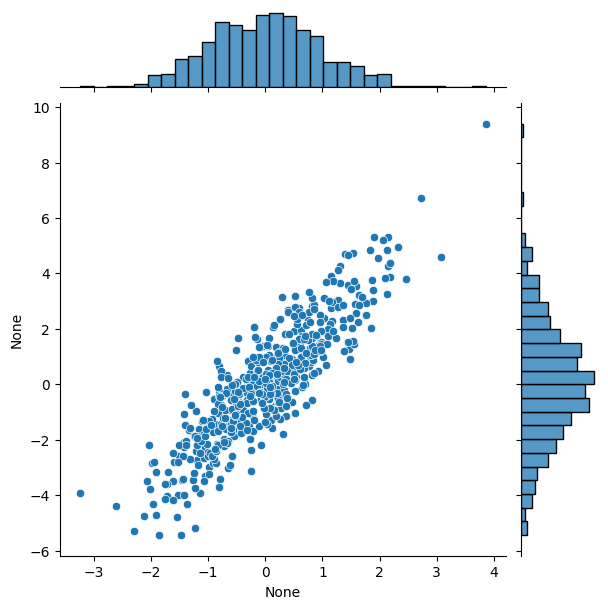

In [4]:
import seaborn as sns
sns.jointplot(x=x, y=y, kind="scatter", marginal_kws=dict(bins=30))
